# Machine Learning using Python on SAS Viya Workbench

## Use Case: Propensity to Purchase

This example uses standard python libraries such as sklearn and pandas. 

The data comes from an anonymized Google Analytics dataset that captures customer interactions and behaviors associated with an online purchasing decision.

We start by loading some data as a pandas dataframe and building a helper function. 


Note that this example is kept relatively simple and by no means includes all steps you would normally take to ensure a quality machine learning model.

Reference: https://www.kaggle.com/datasets/shreekant009/google-analytics/data

In [1]:
import pandas as pd
import numpy as np
import os

WORKSPACE = os.environ['WORKSPACE']
df = pd.read_csv(r"/workspaces/myfolder/data/Google Analytics - v0.csv")

def get_freq(col,df):
    freq1  = df[col].value_counts().to_frame().reset_index()
    freq2 = df[col].value_counts(normalize=True).to_frame().reset_index()

    freq = freq1.set_index(col).join(freq2.set_index(col))

    freq['proportion'] = freq['proportion']*100.0
    
    freq.rename(columns={'proportion':'proportion %'},inplace=True)

    print(freq)

Explore the data a bit.

In [3]:
df.head()

,fullVisitorId,NumberOfTransactions,OrderedAmount,FrequencyRowNumber,MonetoryRowNumber,LastVisitedDays,RecencyScore,FrequecyScore,MonetoryScore,RFMScore,pageviews,sessionQualityDim,referralPath,medium,browser,operatingSystem,isMobile,continent,Ordered
0,1.997560e+17,3,29.96,1,14,70,4,5,4,13,75.0,NaN,NaN,(none),Chrome,Chrome OS,False,Americas,1
1,3.615340e+17,1,13.96,3,30,60,4,5,4,13,12.0,NaN,NaN,(none),Chrome,Macintosh,False,Asia,1
2,9.006670e+18,1,99.99,5,36,60,4,5,4,13,17.0,NaN,NaN,(none),Chrome,Linux,False,Americas,1
3,1.639590e+18,1,59.99,6,49,60,4,5,4,13,19.0,NaN,/,(none),Chrome,Macintosh,False,Americas,1
4,6.914630e+18,1,55.99,9,57,60,4,5,4,13,25.0,NaN,NaN,(none),Chrome,Macintosh,False,Americas,1


We can see some of the columns are spelled incorrectly, so let's correct that now.

In [4]:
df.rename(columns={'FrequecyScore':'FrequencyScore','MonetoryScore':'MonetaryScore',
                   'MonetoryRowNumber':'MonetaryRowNumber'},inplace=True)

Let's take a look at the binary target "Ordered", which indicates if a purchase was made (1) or not (0).

         count  proportion %
Ordered                     
0        12293     99.057212
1          117      0.942788


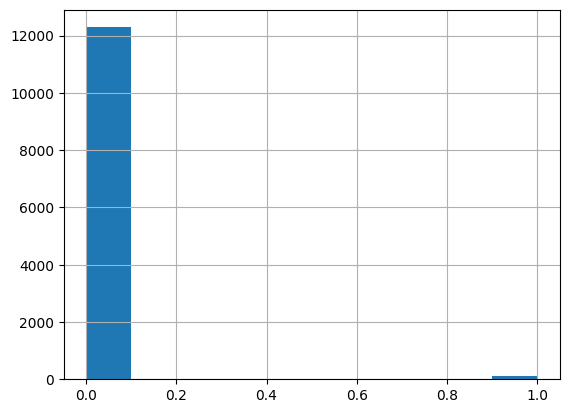

In [25]:
df['Ordered'].hist()

get_freq('Ordered',df)

The data appears to be highly imbalanced, with the number of events being less than 1% of the data. This is highly problematic for machine learning models!

There are a number of ways ways to handle imbalanced data, but I chose a simplified form of oversampling. See this paper for a good overview of methods for tackling imbalanced data. [Handling imbalanced datasets: A review](https://d1wqtxts1xzle7.cloudfront.net/40045253/0c960517fefa59fa6b000000.pdf20151115-68247-1ohdc8j-libre.pdf?1447645886=&response-content-disposition=inline%3B+filename%3DHandling_imbalanced_datasets_A_review.pdf&Expires=1723406115&Signature=Yw8MCYxgDXd8fSGliCXbl~10NlV2I0glyVijPGIINo08QCL6PMNV65dFZOeKBw2zSIkqZYFlzch9gVpQAlY6zeGxOl7cxEH1IP72bZinPQ9YoCh1G3EQ3ae4fHDaanKKtyjwzpW~KLNFvZkP96oJyQ9cRro4LrNRnJpFQLrDyK2XmOL~un6t08bijECvg1uh5Qg6v7dd-ZEvmeZsVPeXkLElxHj2K~Y6FKZhUzu~k3YaF1KRnoGGO62p2TbxLgSkYpaX8eYPAz5k7lHQrl4QfG9F9SqVJtorfo3rD235JFI51px8RWgoE~IZdmFDGo090w9l1TJGbc6Eau5ol6~WFA__&Key-Pair-Id=APKAJLOHF5GGSLRBV4ZA)

For this approach, I use SAS Data Maker to generate synthetic data. For more on SAS Data Maker, please visit the [SAS Data Maker](https://www.sas.com/en_us/software/data-maker.html) homepage.

In [26]:

#Data generated from SAS Data Maker
df_gen = pd.read_csv('/workspaces/myfolder/data/SAS_DataMaker_generated.csv')

df_gen.rename(columns={'FrequecyScore':'FrequencyScore','MonetoryScore':'MonetaryScore',
                   'MonetoryRowNumber':'MonetaryRowNumber'},inplace=True)

df_synth = pd.concat([df,df_gen]).reset_index()

get_freq('Ordered',df_synth)

         count  proportion %
Ordered                     
0        12293     82.448021
1         2617     17.551979


Now we have a much more balanced data set and can proceed. 

## Data Preprocessing

We must perform some data preprocessing to prepare this data for machine learning:

- Useful input variables must be selected (the target is Ordered).
- Categorical variables will be encoded using One Hot encoding and missing values will be replaced.
- A partition must be created to separate training and validation data.



### Variable selection

We simply remove index and ID variables, as well as those that are mostly missing data.

In [8]:
X = df_synth.drop(['RFMScore','OrderedAmount','FrequencyScore','MonetaryScore','RecencyScore','FrequencyRowNumber','MonetaryRowNumber','fullVisitorId','sessionQualityDim','referralPath'], axis=1)
y = df_synth['Ordered']

### Missing value replacement & One Hot Encoding

In [9]:

from sklearn.preprocessing import OneHotEncoder

#check for NaN
X.isna().sum()
X.fillna(0,inplace=True)

y.isna().sum()
y.fillna(0,inplace=True)

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
x_cat = X[categorical_cols]

#get numeric variables
x_num = X.drop(categorical_cols,axis=1)

#create one-hot encoder
ohe = OneHotEncoder(sparse_output = False,handle_unknown='ignore')

#fit
ohe.fit(x_cat)

#encode categorical variables
x_cat_enc = ohe.transform(x_cat)

#convert to data frame
df_x_cat_enc = pd.DataFrame(x_cat_enc,columns=list(ohe.get_feature_names_out()))


#combine categorical and one-hot-encoded into one data frame
x_final = pd.concat([x_num,df_x_cat_enc],axis=1)

### Partition

In [10]:
#We use sklearn to partition the data into training and validation data
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(x_final, y, test_size=0.3, stratify=y, random_state=919)
print("Training data shape:", X_train.shape, "\n" + "Validation data shape:", X_valid.shape)

Training data shape: (10437, 53) 
Validation data shape: (4473, 53)


## Machine Learning 

Now that we have a list of relevant input variables (and cleaned up our data) we ready to start building machine learning models. We will do this in 3 basic steps:
1. Fit
2. Score
3. Assess

We will build 5 different models:
- Simple Logistic Regression
- Decision Tree
- Random Forest
- Tree-based Gradient Boosting
- Support Vector Machine

### Step 1 - Fit the models

In [11]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=500,random_state=0).fit(X_train, y_train)


/usr/local/lib64/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
from sklearn import tree
#decision tree
dtree = tree.DecisionTreeClassifier().fit(X_train,y_train)


In [13]:
from sklearn.ensemble import RandomForestClassifier
#random forest
rforest = RandomForestClassifier(max_depth=2, random_state=0)
rforest.fit(X_train, y_train)

RandomForestClassifier(max_depth=2, random_state=0)

In [14]:
#XGBoost
from xgboost import XGBClassifier
bst = XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic')
# fit model
bst.fit(X_train, y_train)



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [15]:
#SVM
from sklearn import svm
svc = svm.SVC(probability=True).fit(X_train,y_train)


### Step 2 - Score fitted models against training and validation data sets

In [16]:
models = ['logreg','dtree','rforest','bst','svc']

train_out = dict.fromkeys(models, None)
valid_out = dict.fromkeys(models, None)

#score the training and validation data using the models, and join the predictions to the target
for model in models:
    pred = pd.DataFrame(columns = ['P_Ordered'],data=eval(model).predict(X_train))
    pred_proba = pd.DataFrame(columns=['P_Ordered0','P_Ordered1'],data=eval(model).predict_proba(X_train))
    train_out[model] = pred.join(pred_proba)
    train_out[model] = train_out[model].join(y_train.reset_index(drop=True))

    pred = pd.DataFrame(columns = ['P_Ordered'],data=eval(model).predict(X_valid))
    pred_proba = pd.DataFrame(columns=['P_Ordered0','P_Ordered1'],data=eval(model).predict_proba(X_valid))
    valid_out[model] = pred.join(pred_proba)
    valid_out[model] = valid_out[model].join(y_valid.reset_index(drop=True))

### Step 3 - Assess model performance against validation data

In [17]:
from sklearn.metrics import accuracy_score

cutoff = 0.5

for model in models:
    valid_preds = [1 if valid_out[model]['P_Ordered1'][elem] > cutoff else 0 for elem in valid_out[model].index]

    print(f'Misclassification Rate on Validation Data for {model} at',cutoff,'cutoff:', 1-accuracy_score(valid_out[model]['Ordered'], valid_preds))

Misclassification Rate on Validation Data for logreg at 0.5 cutoff: 0.0002235636038453448
Misclassification Rate on Validation Data for dtree at 0.5 cutoff: 0.0
Misclassification Rate on Validation Data for rforest at 0.5 cutoff: 0.0
Misclassification Rate on Validation Data for bst at 0.5 cutoff: 0.0
Misclassification Rate on Validation Data for svc at 0.5 cutoff: 0.15604739548401525
